In [1]:
from pathlib import Path
import xarray as xr
import torch
import torch.nn.functional
from climanet.st_encoder_decoder import SpatioTemporalModel
from climanet.utils import pred_to_numpy, set_seed, configure_compute_resources, plot_results, plot_histograms
from climanet.train import train_monthly_model
from climanet.predict import predict_monthly_var
from climanet import STDataset

from torch.utils.data import random_split
from tbparse import SummaryReader
import matplotlib.pyplot as plt

## Read data

In [ ]:
# without diurnal cycle
data_folder = Path("./eso4clima/dc_data")
run_dir = "./runs_daily"

var_name = "tos"

file_names = [data_folder / f"202101_day_ERA5dc_masked_{var_name}.nc", data_folder / f"202102_day_ERA5dc_masked_{var_name}.nc"]
daily_data = xr.open_mfdataset(file_names, chunks={'time': 1, 'lat': 240, 'lon': 240}).compute()

file_names = [data_folder / f"202101_mon_ERA5dc_full_{var_name}.nc", data_folder / f"202102_mon_ERA5dc_full_{var_name}.nc"]
monthly_data = xr.open_mfdataset(file_names, chunks={'time': 1, 'lat': 240, 'lon': 240}).compute()

file_name = data_folder / "era5_lsm_bool.nc"  # downloded from era5 and regridded using the function `regrid_to_boundary_centered_grid`
lsm_mask = xr.open_dataset(file_name)
lsm_mask = lsm_mask.rename({'latitude': 'lat', 'longitude': 'lon'})

/tmp/ipykernel_1481/55209070.py:8: UserWarning: The specified chunks separate the stored chunks along dimension "lat" starting at index 240. This could degrade performance. Instead, consider rechunking after loading.
  daily_data = xr.open_mfdataset(file_names, chunks={'time': 1, 'lat': 240, 'lon': 240}).compute()
/tmp/ipykernel_1481/55209070.py:8: UserWarning: The specified chunks separate the stored chunks along dimension "lon" starting at index 240. This could degrade performance. Instead, consider rechunking after loading.
  daily_data = xr.open_mfdataset(file_names, chunks={'time': 1, 'lat': 240, 'lon': 240}).compute()
/tmp/ipykernel_1481/55209070.py:8: UserWarning: The specified chunks separate the stored chunks along dimension "lat" starting at index 240. This could degrade performance. Instead, consider rechunking after loading.
  daily_data = xr.open_mfdataset(file_names, chunks={'time': 1, 'lat': 240, 'lon': 240}).compute()
/tmp/ipykernel_1481/55209070.py:8: UserWarning: The 

## Subset data (for fast example)

In [3]:
# coordinates of subset
lon_subset = slice(-50, 50)  # one lon -179.9 is nan, check data
lat_subset = slice(-30, 10)

daily_subset = daily_data.sel(lon=lon_subset, lat=lat_subset)
monthly_subset = monthly_data.sel(lon=lon_subset, lat=lat_subset)
lsm_subset = lsm_mask.sel(lon=lon_subset, lat=lat_subset)  # True=Land

print(daily_subset[var_name].shape, monthly_subset[var_name].shape)  # (time, lat, lon)

(59, 160, 400) (2, 160, 400)


In [4]:
# calculate residuals as target
daily_subset_averaged = daily_subset.resample(time="MS").mean(skipna=True)
daily_subset_averaged["time"] = monthly_subset["time"]

# Residuals
monthly_subset_res = monthly_subset - daily_subset_averaged

## Train the model

In [5]:
# create the model (small)
set_seed()

In [6]:
patch_size = (1, 4, 4)
model = SpatioTemporalModel(patch_size=patch_size, overlap=2, num_months=2, embed_dim=64, dropout=0.2, hidden=64)

In [7]:
# create dataset
patch_size = (1, 4, 4)
num_patches = (10, 10)
spatial_patch_size = (patch_size[1]*num_patches[0], patch_size[2]*num_patches[1])
stride = (spatial_patch_size[0] // 5, spatial_patch_size[1] // 5)

dataset = STDataset(
    input_da=daily_subset[var_name],
    monthly_da=monthly_subset_res[var_name],
    land_mask=lsm_subset["lsm"],
    patch_size=spatial_patch_size,  # based on the patch_size in model
    stride=stride,
    sh_embed_dim=96,
    sh_order_L = 10,
)
print(len(dataset))

Patch grid: 16 x 46 = 736 patches
Overlap: 32 pixels (height), 32 pixels (width)
736


In [8]:
# create train test data
generator = torch.Generator().manual_seed(42)
train_size = int(0.6 * len(dataset))
validation_size = int(0.3 * len(dataset))
test_size = len(dataset) - train_size - validation_size
train_dataset, validation_dataset, test_dataset = random_split(dataset, [train_size, validation_size, test_size], generator=generator)
print(len(train_dataset), len(validation_dataset), len(test_dataset))

441 220 75


### Start training loop

In [9]:
# Device and resources
device = "cpu"
compute_threads = 4
dataloader_num_workers = 2
model = configure_compute_resources(model, device=device, compute_threads=compute_threads, dataloader_num_workers=dataloader_num_workers)

In [10]:
%%time
# verbose is True
batch_size = 10
trained_model = train_monthly_model(
    model, train_dataset, validation_dataset=validation_dataset, batch_size=batch_size, num_epoch=100, accumulation_steps=5, device=device, run_dir=run_dir, dataloader_num_workers=dataloader_num_workers,
)

Epoch 0: gap between train and val loss: -0.001943
Epoch 0: best_loss = 0.020578
Epoch 20: gap between train and val loss: -0.000315
Epoch 20: best_loss = 0.018188
Epoch 40: gap between train and val loss: 0.000122
Epoch 40: best_loss = 0.017894
Epoch 60: gap between train and val loss: 0.000475
Epoch 60: best_loss = 0.017503
Epoch 80: gap between train and val loss: 0.000509
Epoch 80: best_loss = 0.017367
Training complete. Best loss: 0.017260
Model saved to runs_daily/best_model.pth
CPU times: user 1h 57min 59s, sys: 3min 3s, total: 2h 1min 2s
Wall time: 40min 49s


## Inspect results and compare

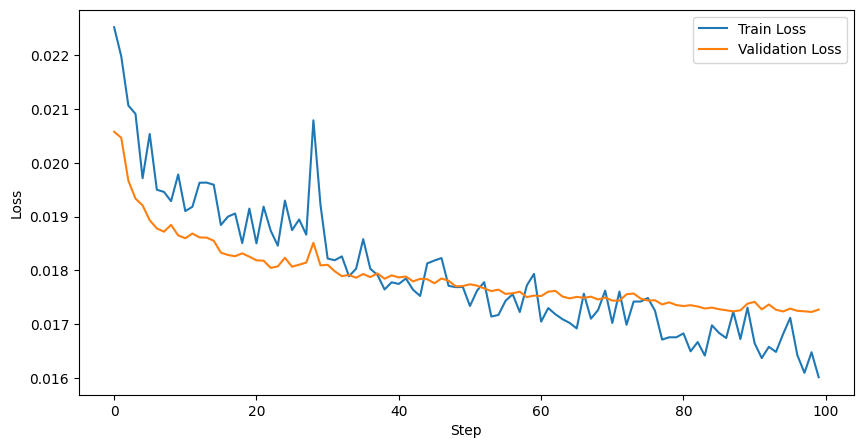

In [11]:
# Load saved training status with tbparse.SummaryReader
reader = SummaryReader(run_dir)

# plot training and validation loss
plt.figure(figsize=(10, 5))
train_loss = reader.scalars[reader.scalars["tag"] == "Loss/train"]
validation_loss = reader.scalars[reader.scalars["tag"] == "Loss/validation"]
plt.plot(train_loss["step"], train_loss["value"], label="Train Loss")
plt.plot(validation_loss["step"], validation_loss["value"], label="Validation Loss")
plt.xlabel("Step")
plt.ylabel("Loss")
plt.legend()

In [12]:
# inference on test data, verbose is True
batch_size = 10
predictions = predict_monthly_var(
    model="runs_daily/best_model.pth", dataset=test_dataset, batch_size=batch_size, save_predictions=True, device=device, run_dir=run_dir, dataloader_num_workers=dataloader_num_workers,
)

Processed batch 1/8, with loss: 0.0181
Processed batch 2/8, with loss: 0.0199
Processed batch 3/8, with loss: 0.0176
Processed batch 4/8, with loss: 0.0174
Processed batch 5/8, with loss: 0.0238
Processed batch 6/8, with loss: 0.0202
Processed batch 7/8, with loss: 0.0257
Processed batch 8/8, with loss: 0.0148
Average loss over all batches: 0.0197
Predictions saved to './runs_daily'


In [13]:
# inference on whole dataset
num_patches = (20, 20)
patch_size = (1, 4, 4)
spatial_patch_size = (patch_size[1]*num_patches[0], patch_size[2]*num_patches[1])

dataset = STDataset(
    input_da=daily_subset[var_name],
    monthly_da=monthly_subset_res[var_name],
    land_mask=lsm_subset["lsm"],
    patch_size=spatial_patch_size,  # based on the patch_size in model
    sh_embed_dim=96,
    sh_order_L = 10,
)
print(len(dataset))

Patch grid: 2 x 5 = 10 patches
Overlap: 0 pixels (height), 0 pixels (width)
10


In [14]:
batch_size = 4
predictions_res = predict_monthly_var(
    model=f"{run_dir}/best_model.pth", dataset=dataset, batch_size=batch_size, verbose=False, save_predictions=True, device=device, run_dir=run_dir, dataloader_num_workers=dataloader_num_workers,
)

In [15]:
# add to monthly average
predictions = daily_subset_averaged[var_name] + predictions_res["predictions"]

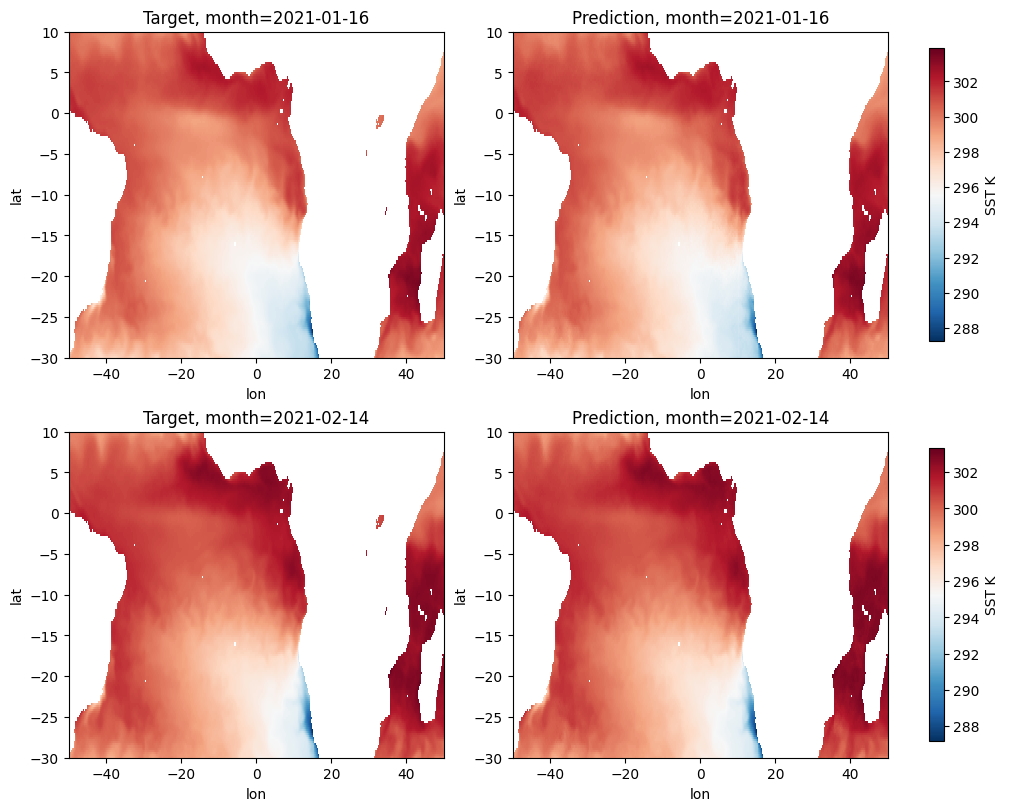

In [16]:
ocean = ~lsm_subset["lsm"].values
masked_target = monthly_subset[var_name].where(ocean)
masked_pred = predictions.where(ocean)
plot_results(masked_target, masked_pred, label="SST K", title=("Target", "Prediction"))

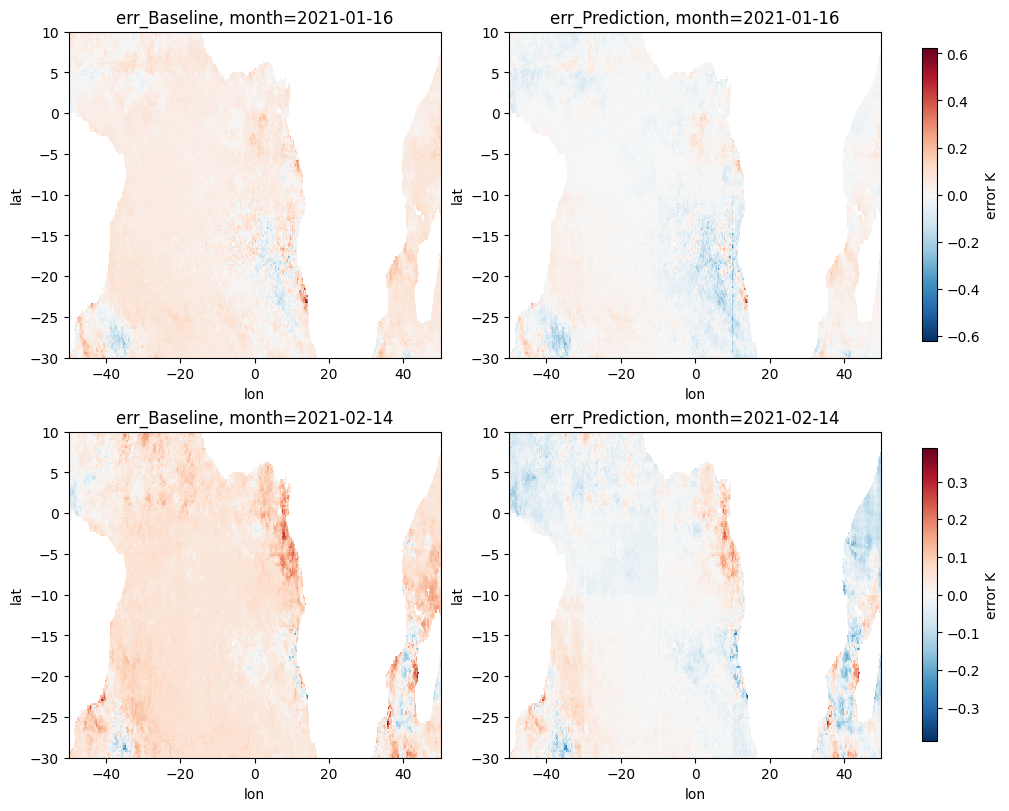

In [17]:
err_baseline = (monthly_subset[var_name] - daily_subset_averaged[var_name])   # M - mean(D)

err_predictions = (monthly_subset[var_name] - predictions)  # M - M_hat

ocean = ~lsm_subset["lsm"].values
masked_err_baseline = err_baseline.where(ocean)
masked_err_predictions = err_predictions.where(ocean) 

plot_results(masked_err_baseline, masked_err_predictions, label="error K", title=("err_Baseline", "err_Prediction"), error=True)

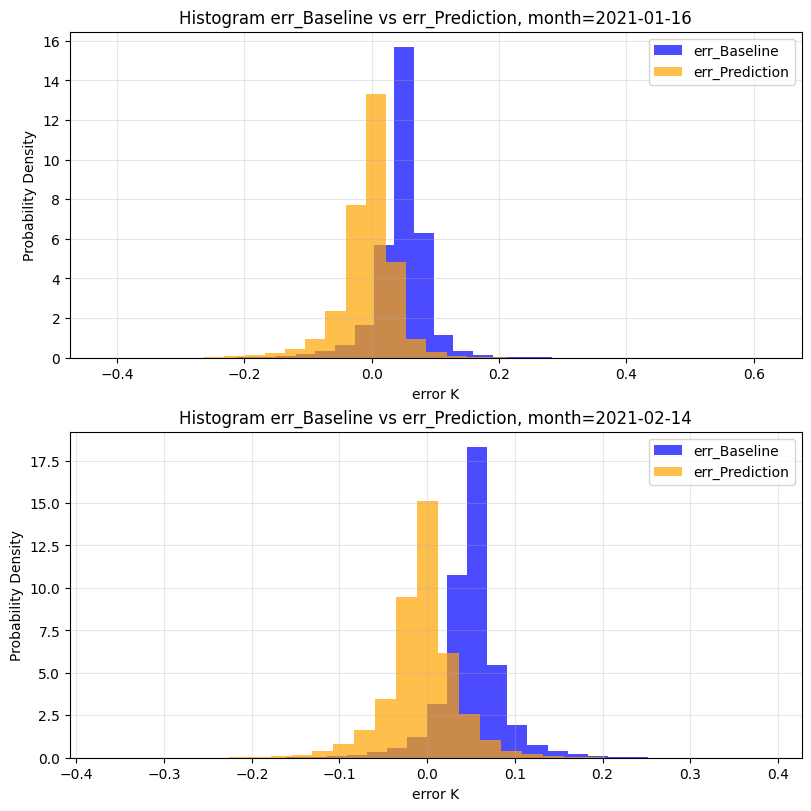

In [18]:
plot_histograms(masked_err_baseline, masked_err_predictions, label="error K", legend_labels=("err_Baseline", "err_Prediction"))